In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel(r"C:\Users\spnra\OneDrive\Documents\CodeAlpha_Task3_Data_Visualization_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,City,Category,Unit_Price,Quantity,Discount_Percent,Payment_Method,Revenue,Cost,Profit
0,TA3-0001,2025-01-01 00:00:00.000,Jaipur,Clothing,1839.04,1,5.55,Credit Card,1736.97,975.84,761.13
1,TA3-0002,2025-01-02 05:13:02.609,Lucknow,Furniture,4788.32,1,5.78,UPI,4511.56,2646.63,1864.93
2,TA3-0003,2025-01-03 10:26:05.217,Hyderabad,Clothing,3416.17,1,16.80,Credit Card,2842.25,1948.82,893.43
3,TA3-0004,2025-01-04 15:39:07.826,Jaipur,Clothing,2464.35,3,0.49,Cash,7356.82,6107.36,1249.46
4,TA3-0005,2025-01-05 20:52:10.435,Bengaluru,Groceries,2515.83,7,2.60,Cash,17152.93,11061.01,6091.92


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (300, 11)

Columns:
Index(['Order_ID', 'Order_Date', 'City', 'Category', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Payment_Method', 'Revenue', 'Cost', 'Profit'],
      dtype='object')

Missing Values:
Order_ID            0
Order_Date          0
City                0
Category            0
Unit_Price          0
Quantity            0
Discount_Percent    6
Payment_Method      8
Revenue             0
Cost                0
Profit              0
dtype: int64


In [7]:
# Missing values ko 0 se fill karna
df = df.fillna(0)

# Missing values check karna
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Order_ID            0
Order_Date          0
City                0
Category            0
Unit_Price          0
Quantity            0
Discount_Percent    0
Payment_Method      0
Revenue             0
Cost                0
Profit              0
dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          300 non-null    object        
 1   Order_Date        300 non-null    datetime64[ns]
 2   City              300 non-null    object        
 3   Category          300 non-null    object        
 4   Unit_Price        300 non-null    float64       
 5   Quantity          300 non-null    int64         
 6   Discount_Percent  300 non-null    float64       
 7   Payment_Method    300 non-null    object        
 8   Revenue           300 non-null    float64       
 9   Cost              300 non-null    float64       
 10  Profit            300 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 25.9+ KB


In [9]:
df.describe()

,Order_Date,Unit_Price,Quantity,Discount_Percent,Revenue,Cost,Profit
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2025-07-02 00:00:00,2580.637367,4.036667,12.653433,9033.935733,6318.053633,2715.882100
min,2025-01-01 00:00:00,112.720000,1.000000,0.000000,190.860000,159.800000,31.060000
25%,2025-04-01 23:59:59.999749888,1395.762500,2.000000,5.835000,3060.282500,2155.240000,794.525000
50%,2025-07-02 00:00:00,2645.155000,4.000000,13.455000,7493.865000,5311.945000,2129.920000
75%,2025-10-01 00:00:00.000250112,3717.660000,6.000000,19.492500,13186.710000,9365.947500,3653.922500
max,2025-12-31 00:00:00,4986.550000,7.000000,24.950000,33330.250000,24263.440000,11955.520000
std,NaN,1392.144008,2.059805,7.493717,7159.703023,5022.684056,2442.330695


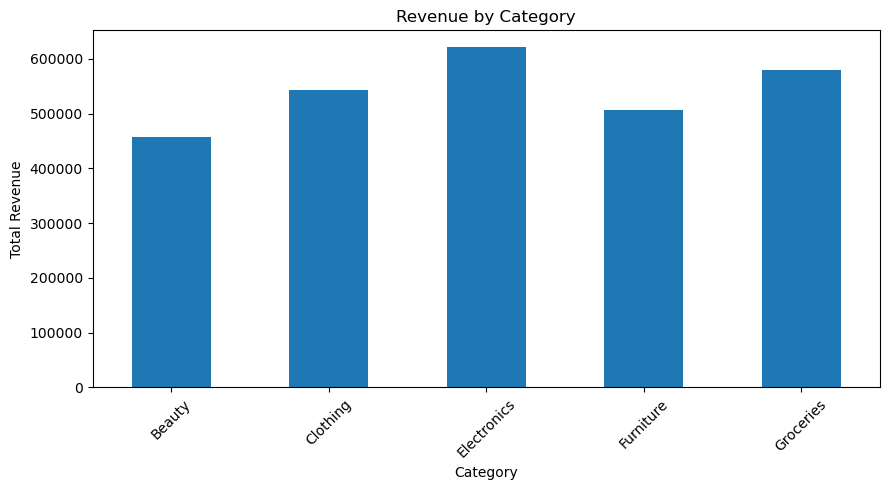

In [10]:
category_revenue = df.groupby("Category")["Revenue"].sum()

plt.figure(figsize=(9, 5))
category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

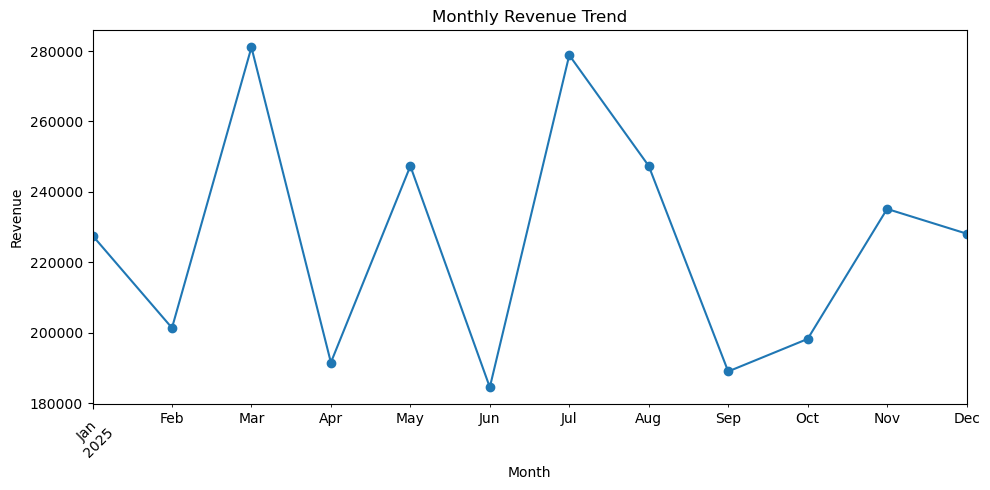

In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_revenue = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()

plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

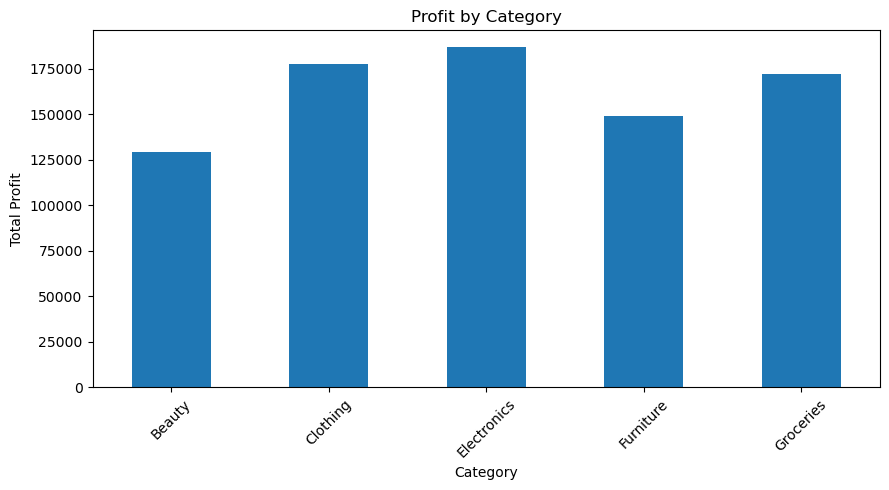

In [12]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(9, 5))
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

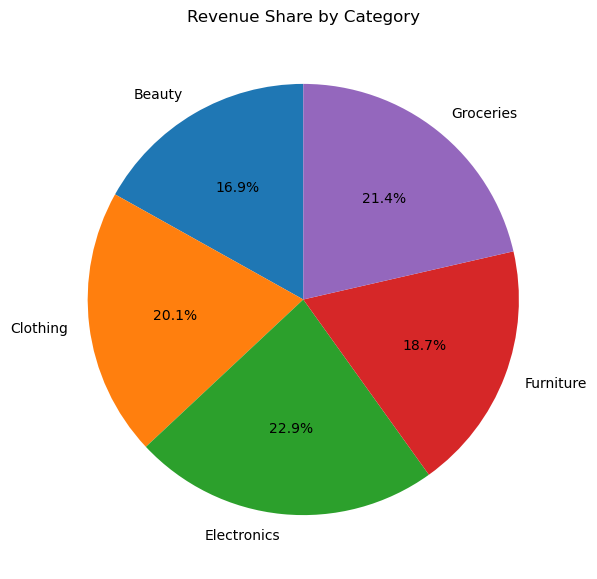

In [13]:
category_revenue = df.groupby("Category")["Revenue"].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Category")
plt.show()

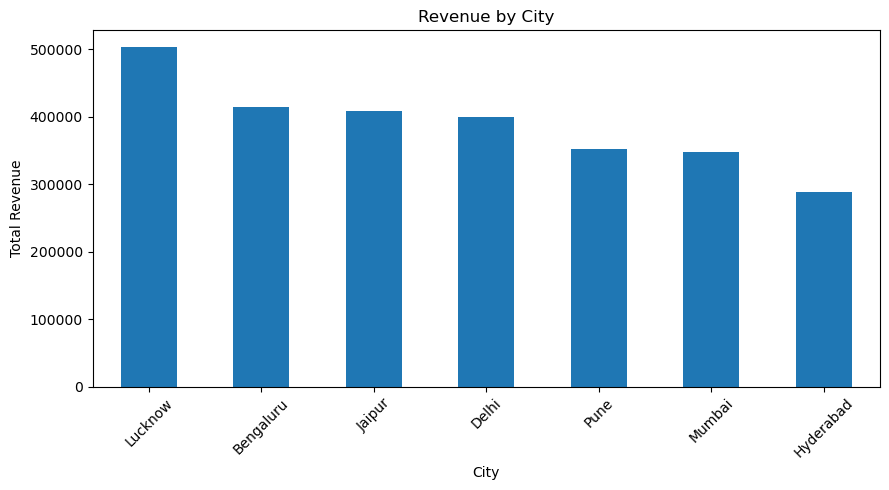

In [14]:
city_revenue = df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

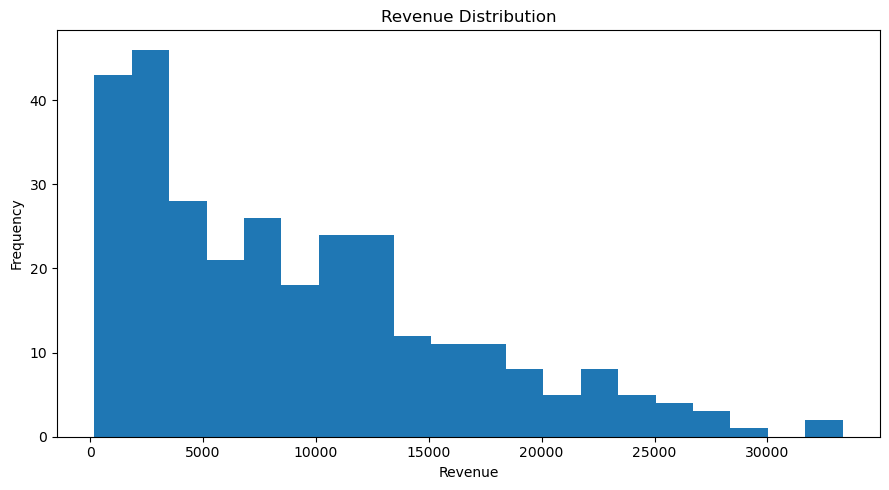

In [15]:
plt.figure(figsize=(9, 5))

plt.hist(df["Revenue"], bins=20)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

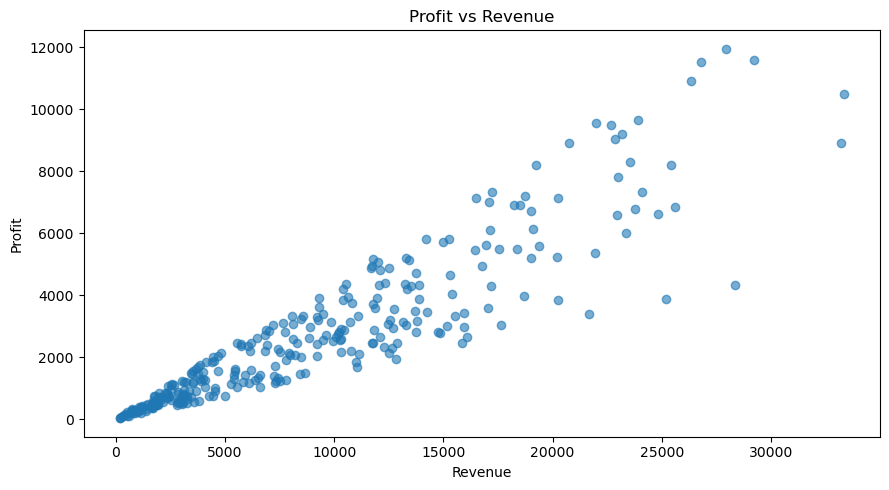

In [16]:
plt.figure(figsize=(9, 5))

plt.scatter(df["Revenue"], df["Profit"], alpha=0.6)

plt.title("Profit vs Revenue")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

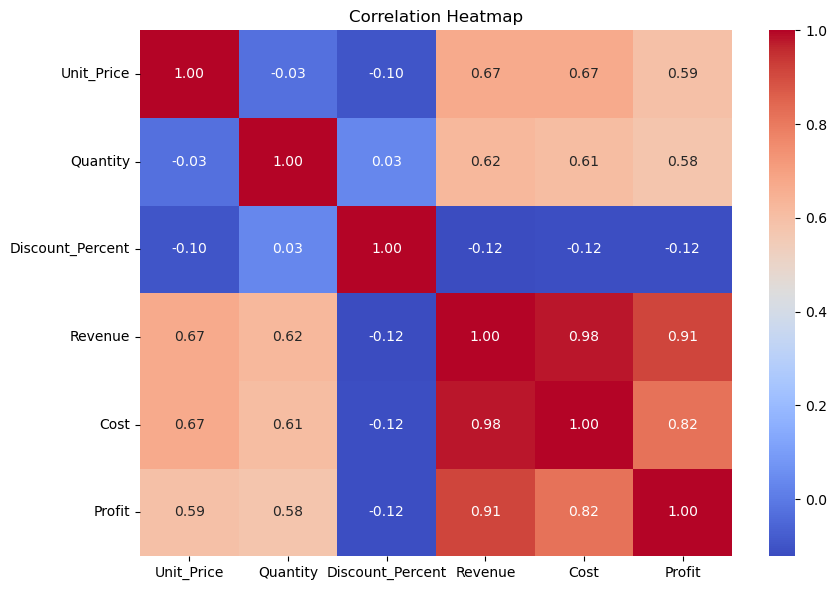

In [17]:
numeric_data = df[
    ["Unit_Price", "Quantity", "Discount_Percent",
     "Revenue", "Cost", "Profit"]
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

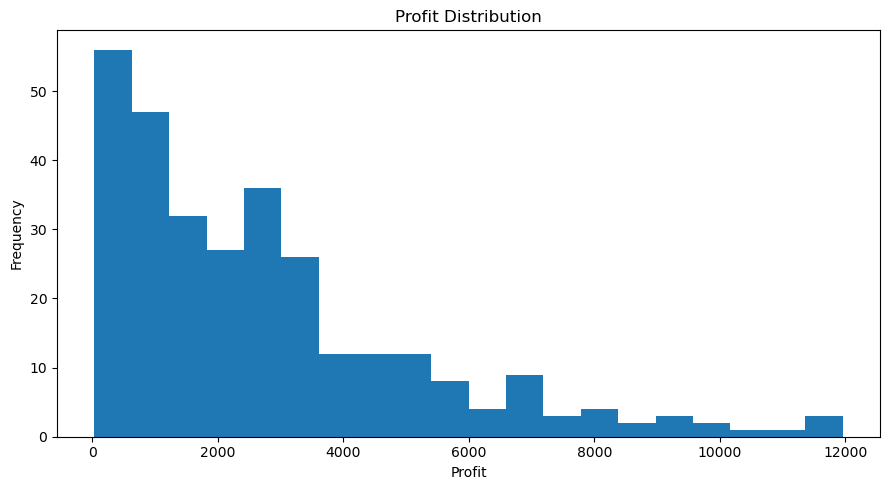

In [18]:
plt.figure(figsize=(9, 5))

plt.hist(df["Profit"], bins=20)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

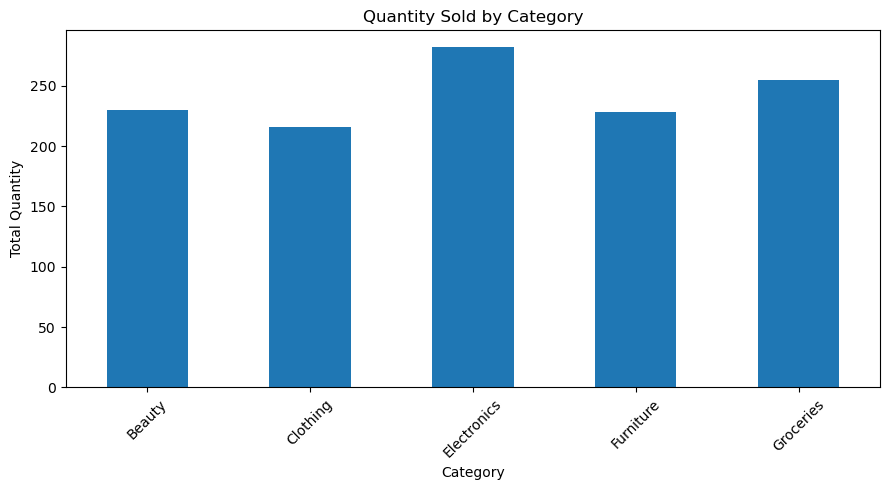

In [19]:
category_quantity = df.groupby("Category")["Quantity"].sum()

plt.figure(figsize=(9, 5))
category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

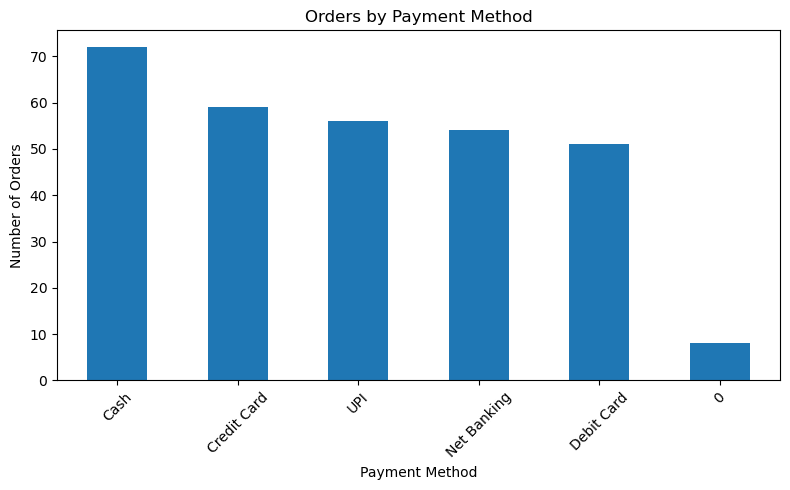

In [20]:
payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(8, 5))
payment_counts.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
print("Total Revenue:", round(df["Revenue"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))

print(
    "Highest Revenue Category:",
    df.groupby("Category")["Revenue"].sum().idxmax()
)

print(
    "Highest Profit Category:",
    df.groupby("Category")["Profit"].sum().idxmax()
)

print(
    "Highest Revenue City:",
    df.groupby("City")["Revenue"].sum().idxmax()
)

print(
    "Highest Quantity Category:",
    df.groupby("Category")["Quantity"].sum().idxmax()
)

Total Revenue: 2710180.72
Total Profit: 814764.63
Highest Revenue Category: Electronics
Highest Profit Category: Electronics
Highest Revenue City: Lucknow
Highest Quantity Category: Electronics


## Conclusion

The data visualization analysis provided a clear understanding of sales
performance across categories, cities, months, revenue, and profit.

Different visualization techniques were used to identify trends,
comparisons, distributions, and relationships in the dataset.

The analysis demonstrates how data visualization can convert raw sales
data into meaningful and easy-to-understand insights.

Overall, the project helped in understanding sales performance and
supporting data-driven decision making.